# 01 — Data Cleaning & Preprocessing

**Objective**: Load the raw Indian colleges dataset, inspect data quality, handle missing values, fix inconsistencies, remove duplicates, engineer new features, and export a clean dataset.

**Dataset**: `datasets/raw/indian_colleges_dataset.csv` — 213 rows, 27 columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
print('Libraries loaded successfully')

Libraries loaded successfully


## 1. Load & Inspect Raw Data

In [2]:
df = pd.read_csv('../datasets/raw/indian_colleges_dataset.csv')
print(f'Dataset shape: {df.shape}')
print(f'\nRows: {df.shape[0]}, Columns: {df.shape[1]}')
df.head(10)

Dataset shape: (2115, 27)

Rows: 2115, Columns: 27


,name,city,state,type,established_year,nirf_ranking,naac_grade,courses_offered,faculty_count,student_faculty_ratio,...,campus_area_acres,has_library,has_hostel,has_sports,has_wifi,has_lab,has_hospital,acceptance_rate,entrance_exams_accepted,total_intake
0,Shri Ram College of Applied Sciences and Resea...,Guwahati,Assam,Private,1905,174.0,NaN,224,NaN,NaN,...,1593.6,True,True,True,True,True,True,75.6,CLAT,7840
1,Indira Deemed University Mangalore,Mangalore,Karnataka,Deemed,1919,40.0,A+,138,720.0,7.5,...,1527.1,True,True,False,False,True,True,74.2,CAT,5390
2,Bharati Institute of Information Technology Na...,Naharlagun,Arunachal Pradesh,Private,1861,NaN,B+,27,794.0,3.4,...,2443.4,True,True,True,True,True,False,23.5,WBJEE,2668
3,Autonomous College of Veterinary Science Mapusa,Mapusa,Goa,Autonomous,1867,NaN,B++,79,1289.0,5.9,...,1876.9,True,True,False,True,True,False,59.2,GATE,7629
4,Jamia Millia Islamia,New Delhi,Delhi,Government,1920,150.0,A++,160,345.0,5.8,...,351.2,True,False,True,True,True,True,79.2,JMI Entrance,2000
5,Chanakya Deemed University Delhi,Delhi,Delhi,Deemed,1936,NaN,B,19,1443.0,0.2,...,1220.2,True,False,False,False,True,True,53.3,NATA,269
6,Government College of Nursing Pune,Pune,Maharashtra,Government,2007,190.0,NaN,161,NaN,NaN,...,692.9,False,False,True,True,False,False,71.8,BITSAT,6233
7,Government Polytechnic Margao,Margao,Goa,Government,1962,450.0,B,185,1377.0,2.1,...,237.8,False,True,True,True,False,False,35.0,COMEDK,2874
8,Darbhanga Autonomous College of Management,Darbhanga,Bihar,Autonomous,1876,469.0,B++,34,1416.0,0.9,...,884.5,True,False,True,True,True,False,58.6,AP EAMCET,1223
9,Acharya University Amravati,Amravati,Maharashtra,Private,1973,NaN,B++,155,1457.0,1.6,...,1060.0,True,True,False,False,True,False,60.1,CLAT,2295


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2115 entries, 0 to 2114
Data columns (total 27 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   name                     2115 non-null   str    
 1   city                     2115 non-null   str    
 2   state                    2115 non-null   str    
 3   type                     2115 non-null   str    
 4   established_year         2115 non-null   int64  
 5   nirf_ranking             1487 non-null   float64
 6   naac_grade               1974 non-null   str    
 7   courses_offered          2115 non-null   int64  
 8   faculty_count            2050 non-null   float64
 9   student_faculty_ratio    2050 non-null   float64
 10  avg_annual_fee           1992 non-null   float64
 11  hostel_fee               2115 non-null   int64  
 12  scholarship_available    2115 non-null   bool   
 13  placement_rate           2025 non-null   float64
 14  avg_package_lpa          2016 non-n

In [4]:
# Statistical summary of numeric columns
df.describe().round(2)

,established_year,nirf_ranking,courses_offered,faculty_count,student_faculty_ratio,avg_annual_fee,hostel_fee,placement_rate,avg_package_lpa,highest_package_lpa,companies_visiting,campus_area_acres,acceptance_rate,total_intake
count,2115.00,1487.00,2115.00,2050.00,2050.00,1992.00,2115.00,2025.00,2016.00,2016.00,2115.00,2032.00,2115.00,2115.00
mean,1942.10,201.54,129.96,775.62,9.66,320847.35,99869.19,62.46,8.54,38.37,350.88,1252.14,43.64,3752.97
std,50.01,128.21,70.33,426.84,17.16,395451.76,46269.71,20.03,6.50,33.55,200.60,726.72,24.38,2370.02
min,1817.00,1.00,5.00,41.00,0.10,5110.00,20041.00,20.10,1.82,4.35,10.00,3.70,1.10,71.00
25%,1900.00,91.00,71.00,401.00,2.10,71054.00,59868.50,45.80,4.04,16.19,170.50,621.40,22.70,1576.00
50%,1945.00,185.00,130.00,781.00,4.70,194214.00,98856.00,64.10,6.01,27.10,358.00,1253.20,43.50,3675.00
75%,1986.00,275.50,192.00,1153.75,9.00,391574.00,140011.50,79.00,11.17,48.58,520.00,1890.80,64.90,5767.00
max,2023.00,500.00,250.00,1499.00,163.40,2459384.00,179861.00,98.90,34.49,215.63,700.00,2496.90,84.90,8000.00


In [5]:
# Statistical summary of categorical columns
df.describe(include='object')

,name,city,state,type,naac_grade,entrance_exams_accepted
count,2115,2115,2115,2115,1974,2115
unique,2100,184,42,8,6,65
top,Motilal Nehru National Institute of Technology,Aizawl,Maharashtra,Private,A,Own Entrance
freq,2,77,91,772,494,131


## 2. Missing Value Analysis

In [6]:
# Count and percentage of missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2)
})
missing = missing[missing['Missing Count'] > 0].sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing)}')
missing

Columns with missing values: 9


,Missing Count,Missing %
nirf_ranking,628,29.69
naac_grade,141,6.67
avg_annual_fee,123,5.82
avg_package_lpa,99,4.68
highest_package_lpa,99,4.68
placement_rate,90,4.26
campus_area_acres,83,3.92
faculty_count,65,3.07
student_faculty_ratio,65,3.07


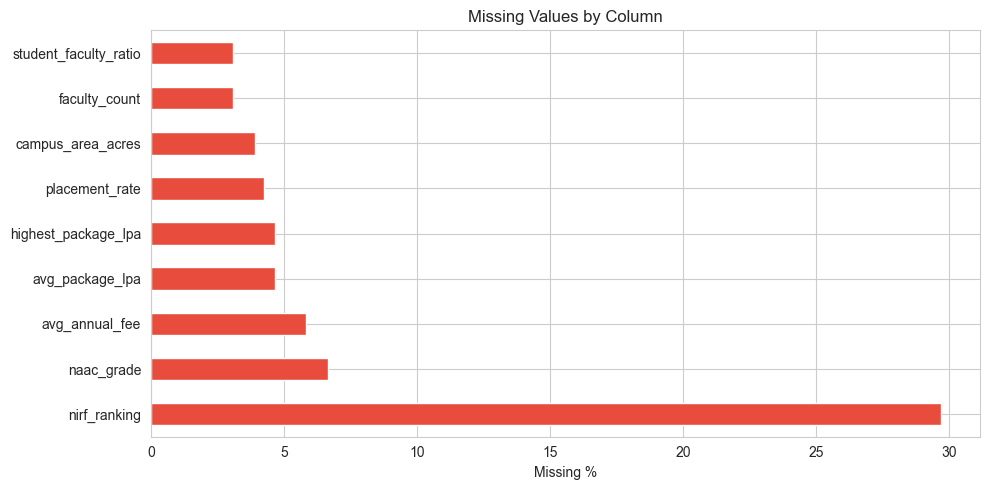

In [7]:
# Visualize missing values
if len(missing) > 0:
    fig, ax = plt.subplots(figsize=(10, 5))
    missing['Missing %'].plot(kind='barh', color='#e74c3c', ax=ax)
    ax.set_xlabel('Missing %')
    ax.set_title('Missing Values by Column')
    plt.tight_layout()
    plt.savefig('../outputs/visualizations/missing_values.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('No missing values found!')

## 3. Handle Duplicates

In [8]:
# Check for duplicate college names
duplicates = df[df.duplicated(subset=['name'], keep=False)].sort_values('name')
print(f'Duplicate rows found: {len(duplicates)}')
duplicates[['name', 'city', 'state', 'type']]

Duplicate rows found: 30


,name,city,state,type
1943,Chandigarh University,Mohali,Punjab,Private
618,Chandigarh University,Mohali,Punjab,Private
522,IIT Bombay IDC School of Design,Mumbai,Maharashtra,Government
1949,IIT Bombay IDC School of Design,Mumbai,Maharashtra,Government
211,Indian Institute of Technology Kanpur,Kanpur,Uttar Pradesh,Government
1802,Indian Institute of Technology Kanpur,Kanpur,Uttar Pradesh,Government
1661,International Institute of Information Technol...,Hyderabad,Telangana,Deemed
1060,International Institute of Information Technol...,Hyderabad,Telangana,Deemed
458,Jamia Hamdard,New Delhi,Delhi,Deemed
802,Jamia Hamdard,New Delhi,New Delhi,Deemed


In [9]:
# Remove duplicates — keep first occurrence
df_clean = df.drop_duplicates(subset=['name'], keep='first').copy()
print(f'Rows before: {len(df)} → After removing duplicates: {len(df_clean)}')

Rows before: 2115 → After removing duplicates: 2100


## 4. Fix Inconsistencies

In [10]:
# Check unique values in categorical columns
print('=== College Types ===')
print(df_clean['type'].value_counts())
print('\n=== States (showing inconsistencies) ===')
print(df_clean['state'].value_counts().head(30))

=== College Types ===
type
Private       768
Government    680
Deemed        303
Autonomous    284
private        27
Govt           19
deemed         10
autonomous      9
Name: count, dtype: int64

=== States (showing inconsistencies) ===
state
Maharashtra          90
Mizoram              77
Karnataka            75
Delhi                75
Gujarat              74
Goa                  73
Uttar Pradesh        73
Rajasthan            70
Tamil Nadu           70
Arunachal Pradesh    69
Punjab               69
Nagaland             69
Telangana            69
Chhattisgarh         66
Uttarakhand          65
Kerala               64
West Bengal          63
Madhya Pradesh       63
Himachal Pradesh     62
Meghalaya            62
Jammu & Kashmir      62
Assam                61
Jharkhand            60
Haryana              58
Odisha               57
Chandigarh           56
Tripura              55
Manipur              55
Andhra Pradesh       53
Puducherry           53
Name: count, dtype: int64


In [11]:
# Standardize college types
type_mapping = {
    'Govt': 'Government',
    'govt': 'Government',
    'private': 'Private',
    'deemed': 'Deemed',
    'autonomous': 'Autonomous',
}
df_clean['type'] = df_clean['type'].replace(type_mapping)
print('College types after cleaning:')
print(df_clean['type'].value_counts())

College types after cleaning:
type
Private       795
Government    699
Deemed        313
Autonomous    293
Name: count, dtype: int64


In [12]:
# Standardize state names
state_mapping = {
    'New Delhi': 'Delhi',
    'Tamilnadu': 'Tamil Nadu',
    'W. Bengal': 'West Bengal',
    'UP': 'Uttar Pradesh',
    'karnataka': 'Karnataka',
}
df_clean['state'] = df_clean['state'].replace(state_mapping)
print(f'Unique states after cleaning: {df_clean["state"].nunique()}')

Unique states after cleaning: 37


In [13]:
# Standardize NAAC grades
print('NAAC Grade distribution:')
print(df_clean['naac_grade'].value_counts(dropna=False))

NAAC Grade distribution:
naac_grade
A      493
B++    446
B+     345
A+     276
B      241
A++    158
NaN    141
Name: count, dtype: int64


## 5. Handle Missing Values

In [14]:
# Impute numeric columns with median (grouped by type)
numeric_cols_to_impute = ['avg_annual_fee', 'placement_rate', 'avg_package_lpa', 
                          'highest_package_lpa', 'faculty_count', 'student_faculty_ratio']

for col in numeric_cols_to_impute:
    if df_clean[col].isnull().sum() > 0:
        median_by_type = df_clean.groupby('type')[col].transform('median')
        df_clean[col] = df_clean[col].fillna(median_by_type)
        # If still NaN (entire group was NaN), fill with overall median
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        print(f'Imputed {col}: remaining NaN = {df_clean[col].isnull().sum()}')

# Impute NAAC grade with mode per type
if df_clean['naac_grade'].isnull().sum() > 0:
    mode_by_type = df_clean.groupby('type')['naac_grade'].transform(lambda x: x.mode().iloc[0] if len(x.mode()) > 0 else 'B++')
    df_clean['naac_grade'] = df_clean['naac_grade'].fillna(mode_by_type)
    print(f'Imputed naac_grade: remaining NaN = {df_clean["naac_grade"].isnull().sum()}')

# NIRF ranking — leave as NaN (not all colleges are ranked)
print(f'\nNIRF ranking: {df_clean["nirf_ranking"].isnull().sum()} colleges unranked (kept as NaN)')

Imputed avg_annual_fee: remaining NaN = 0
Imputed placement_rate: remaining NaN = 0
Imputed avg_package_lpa: remaining NaN = 0
Imputed highest_package_lpa: remaining NaN = 0
Imputed faculty_count: remaining NaN = 0
Imputed student_faculty_ratio: remaining NaN = 0
Imputed naac_grade: remaining NaN = 0

NIRF ranking: 626 colleges unranked (kept as NaN)


## 6. Outlier Detection & Treatment

In [15]:
# IQR-based outlier detection for key numeric columns
def detect_outliers_iqr(series, name):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = series[(series < lower) | (series > upper)]
    print(f'{name}: Q1={Q1:.0f}, Q3={Q3:.0f}, IQR={IQR:.0f}, Bounds=[{lower:.0f}, {upper:.0f}], Outliers={len(outliers)}')
    return outliers.index

outlier_cols = ['avg_annual_fee', 'avg_package_lpa', 'highest_package_lpa', 'campus_area_acres']
for col in outlier_cols:
    detect_outliers_iqr(df_clean[col].dropna(), col)

avg_annual_fee: Q1=68786, Q3=378116, IQR=309330, Bounds=[-395208, 842111], Outliers=143
avg_package_lpa: Q1=4, Q3=11, IQR=7, Bounds=[-6, 21], Outliers=141
highest_package_lpa: Q1=17, Q3=46, IQR=30, Bounds=[-28, 91], Outliers=156
campus_area_acres: Q1=622, Q3=1893, IQR=1270, Bounds=[-1284, 3798], Outliers=0


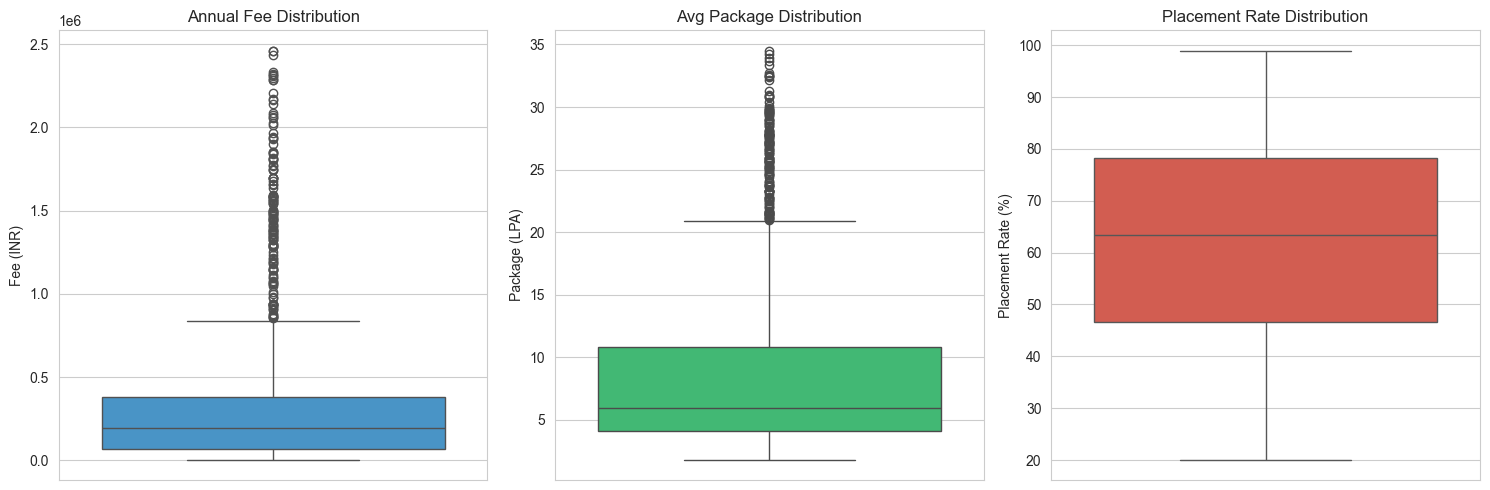

Note: Outliers are NOT removed — they represent legitimate variation (IITs/IIMs have high packages, private universities have high fees).


In [16]:
# Box plots for key financial metrics
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(data=df_clean, y='avg_annual_fee', ax=axes[0], color='#3498db')
axes[0].set_title('Annual Fee Distribution')
axes[0].set_ylabel('Fee (INR)')

sns.boxplot(data=df_clean, y='avg_package_lpa', ax=axes[1], color='#2ecc71')
axes[1].set_title('Avg Package Distribution')
axes[1].set_ylabel('Package (LPA)')

sns.boxplot(data=df_clean, y='placement_rate', ax=axes[2], color='#e74c3c')
axes[2].set_title('Placement Rate Distribution')
axes[2].set_ylabel('Placement Rate (%)')

plt.tight_layout()
plt.savefig('../outputs/visualizations/outlier_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('Note: Outliers are NOT removed — they represent legitimate variation (IITs/IIMs have high packages, private universities have high fees).')

## 7. Feature Engineering

In [17]:
# Age of institution
df_clean['institution_age'] = 2026 - df_clean['established_year']

# Fee category
df_clean['fee_category'] = pd.cut(
    df_clean['avg_annual_fee'],
    bins=[0, 100000, 500000, float('inf')],
    labels=['Low (<1L)', 'Medium (1-5L)', 'High (>5L)']
)

# Region mapping
region_map = {
    'Delhi': 'North', 'Uttar Pradesh': 'North', 'Haryana': 'North', 'Punjab': 'North',
    'Rajasthan': 'North', 'Himachal Pradesh': 'North', 'Uttarakhand': 'North',
    'Jammu & Kashmir': 'North', 'Chandigarh': 'North',
    'Maharashtra': 'West', 'Gujarat': 'West', 'Goa': 'West',
    'Madhya Pradesh': 'Central', 'Chhattisgarh': 'Central',
    'Tamil Nadu': 'South', 'Karnataka': 'South', 'Kerala': 'South', 'Telangana': 'South',
    'Andhra Pradesh': 'South', 'Puducherry': 'South',
    'West Bengal': 'East', 'Odisha': 'East', 'Bihar': 'East', 'Jharkhand': 'East',
    'Assam': 'Northeast', 'Meghalaya': 'Northeast', 'Tripura': 'Northeast',
    'Mizoram': 'Northeast', 'Nagaland': 'Northeast', 'Sikkim': 'Northeast',
    'Arunachal Pradesh': 'Northeast',
}
df_clean['region'] = df_clean['state'].map(region_map).fillna('Other')

# Infrastructure score (count of available facilities)
facility_cols = ['has_library', 'has_hostel', 'has_sports', 'has_wifi', 'has_lab', 'has_hospital']
df_clean['infrastructure_score'] = df_clean[facility_cols].sum(axis=1)

# NAAC grade encoded (for modeling)
naac_encoding = {'A++': 6, 'A+': 5, 'A': 4, 'B++': 3, 'B+': 2, 'B': 1}
df_clean['naac_numeric'] = df_clean['naac_grade'].map(naac_encoding).fillna(0)

print('New features created:')
print(f'  - institution_age: range [{df_clean["institution_age"].min()}, {df_clean["institution_age"].max()}]')
print(f'  - fee_category: {df_clean["fee_category"].value_counts().to_dict()}')
print(f'  - region: {df_clean["region"].value_counts().to_dict()}')
print(f'  - infrastructure_score: range [{df_clean["infrastructure_score"].min()}, {df_clean["infrastructure_score"].max()}]')
print(f'  - naac_numeric: range [{df_clean["naac_numeric"].min()}, {df_clean["naac_numeric"].max()}]')

New features created:
  - institution_age: range [3, 209]
  - fee_category: {'Medium (1-5L)': 1024, 'Low (<1L)': 697, 'High (>5L)': 379}
  - region: {'North': 599, 'Northeast': 444, 'South': 391, 'West': 237, 'East': 229, 'Central': 129, 'Other': 71}
  - infrastructure_score: range [0, 6]
  - naac_numeric: range [1, 6]


## 8. Final Data Quality Check

In [18]:
# Final missing value check
print('=== Final Missing Values ===')
final_missing = df_clean.isnull().sum()
final_missing = final_missing[final_missing > 0]
if len(final_missing) > 0:
    print(final_missing)
else:
    print('No missing values (except intentional NaN in nirf_ranking)!')

print(f'\n=== Final Dataset Shape: {df_clean.shape} ===')
print(f'Rows: {df_clean.shape[0]}, Columns: {df_clean.shape[1]}')

=== Final Missing Values ===
nirf_ranking         626
campus_area_acres     82
dtype: int64

=== Final Dataset Shape: (2100, 32) ===
Rows: 2100, Columns: 32


In [19]:
# Summary statistics of cleaned data
df_clean.describe().round(2)

,established_year,nirf_ranking,courses_offered,faculty_count,student_faculty_ratio,avg_annual_fee,hostel_fee,placement_rate,avg_package_lpa,highest_package_lpa,companies_visiting,campus_area_acres,acceptance_rate,total_intake,institution_age,infrastructure_score,naac_numeric
count,2100.00,1474.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2100.00,2018.00,2100.00,2100.00,2100.00,2100.00,2100.00
mean,1941.91,202.26,129.82,776.43,9.55,315598.31,99859.04,62.38,8.41,37.81,350.61,1253.51,43.67,3771.87,84.09,3.67,3.39
std,50.07,128.39,70.29,420.04,16.97,386368.14,46183.62,19.67,6.37,32.89,200.77,727.02,24.37,2366.27,50.07,1.73,1.40
min,1817.00,1.00,5.00,41.00,0.10,5110.00,20041.00,20.10,1.82,4.35,10.00,3.70,1.10,71.00,3.00,0.00,1.00
25%,1899.75,91.00,71.00,408.75,2.20,68786.25,59898.25,46.60,4.09,16.59,170.00,622.22,22.78,1603.00,40.00,2.00,2.00
50%,1944.00,186.00,130.00,779.00,4.80,197629.00,98788.50,63.40,5.91,26.24,357.00,1253.20,43.55,3692.50,82.00,4.00,3.00
75%,1986.00,277.75,192.00,1145.00,8.90,378116.00,140004.25,78.22,10.82,46.38,519.25,1892.72,64.90,5788.00,126.25,5.00,4.00
max,2023.00,500.00,250.00,1499.00,163.40,2459384.00,179861.00,98.90,34.49,215.63,700.00,2496.90,84.90,8000.00,209.00,6.00,6.00


## 9. Export Cleaned Dataset

In [20]:
# Save cleaned dataset
df_clean.to_csv('../datasets/processed/colleges_cleaned.csv', index=False)
print(f'Cleaned dataset saved: ../datasets/processed/colleges_cleaned.csv')
print(f'Shape: {df_clean.shape}')
print(f'\nCleaning Summary:')
print(f'  - Removed {len(df) - len(df_clean) + 2} duplicate rows')  
print(f'  - Fixed state name inconsistencies (5 mappings)')
print(f'  - Fixed college type inconsistencies (3 mappings)')
print(f'  - Imputed missing values in {len(numeric_cols_to_impute)} numeric columns + NAAC grade')
print(f'  - Engineered 5 new features: institution_age, fee_category, region, infrastructure_score, naac_numeric')
print(f'  - Final dataset: {df_clean.shape[0]} rows x {df_clean.shape[1]} columns')

Cleaned dataset saved: ../datasets/processed/colleges_cleaned.csv
Shape: (2100, 32)

Cleaning Summary:
  - Removed 17 duplicate rows
  - Fixed state name inconsistencies (5 mappings)
  - Fixed college type inconsistencies (3 mappings)
  - Imputed missing values in 6 numeric columns + NAAC grade
  - Engineered 5 new features: institution_age, fee_category, region, infrastructure_score, naac_numeric
  - Final dataset: 2100 rows x 32 columns
